In [1]:
import pandas as pd
import numpy as np 

df=pd.read_csv("../data/online_retail.csv/cleaned_retail.csv")

df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [3]:
cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days = 30)

In [4]:
historical_df = df[df['InvoiceDate']<=cutoff_date]
future_df = df[df['InvoiceDate']>cutoff_date]

In [7]:
#Build RFM for historical data 

snapshot_date = historical_df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [14]:
rfm_ml = historical_df.groupby('Customer ID').agg({
    'InvoiceDate':lambda x: (snapshot_date - x.max()).days,
    'Invoice':'nunique',
    'Revenue':'sum'
})

rfm_ml.columns=['Recency','Frequency','Monetary']

In [15]:
future_customers=future_df['Customer ID'].unique()

In [16]:
rfm_ml['Target']=np.where(rfm_ml.index.isin(future_customers),1,0)

In [17]:
rfm_ml['Target'].value_counts()

Target
0    4230
1    1487
Name: count, dtype: int64

In [22]:
x=rfm_ml[['Recency','Frequency','Monetary']]

In [23]:
y = rfm_ml['Target']

In [24]:
#Train-test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#scaling features for the sake of maintaning consistency 
#log transform 
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

In [26]:
#scaling 
from sklearn.preprocessing import StandardScaler

scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(X_train_log)
X_test_scaled = scaler_ml.transform(X_test_log)

In [29]:
#train xgboost 

from xgboost import XGBClassifier

#create model 
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

In [30]:
#fit model 

model.fit(
    X_train_scaled,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [31]:
#make predictions 

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [32]:
#evaluating model 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

In [33]:
#metrics 

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7805944055944056
Precision: 0.6477987421383647
Recall: 0.34563758389261745
ROC-AUC: 0.7480544052548908


most important metric here is ROC-AUC as probabilities matter and class-imbalance exists 


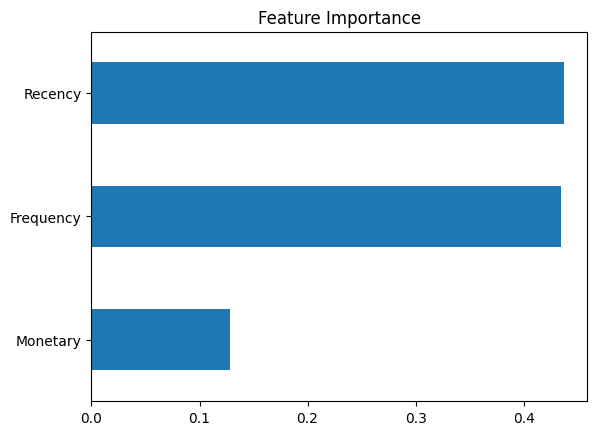

In [34]:
import matplotlib.pyplot as plt
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh'
)

plt.title("Feature Importance")

plt.show()

In [35]:
predictions = X_test.copy()

predictions['Actual'] = y_test
predictions['Predicted_Probability'] = y_prob

predictions.head()

,Recency,Frequency,Monetary,Actual,Predicted_Probability
Customer ID,,,,,
16163.0,202,6,2849.58,0,0.238172
17698.0,231,1,154.95,0,0.031987
15806.0,16,3,784.58,0,0.323802
14758.0,115,7,2864.97,0,0.353033
16481.0,652,1,453.38,0,0.012823


In [36]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_propensity_model.pkl"
)

joblib.dump(
    scaler_ml,
    "../models/propensity_scaler.pkl"
)

['../models/propensity_scaler.pkl']

In [37]:
import numpy as np

X_train_log = np.log1p(X_train)

X_test_log = np.log1p(X_test)

from sklearn.preprocessing import StandardScaler

scaler_ml = StandardScaler()
X_train_scaled = scaler_ml.fit_transform(
    X_train_log
)
X_test_scaled = scaler_ml.transform(
    X_test_log
)
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train_scaled,
    y_train
)
y_pred = model.predict(
    X_test_scaled
)
y_prob = model.predict_proba(
    X_test_scaled
)[:,1]

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7805944055944056
Precision: 0.6477987421383647
Recall: 0.34563758389261745
ROC-AUC: 0.7480544052548908


In [40]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       846
           1       0.65      0.35      0.45       298

    accuracy                           0.78      1144
   macro avg       0.72      0.64      0.66      1144
weighted avg       0.76      0.78      0.76      1144



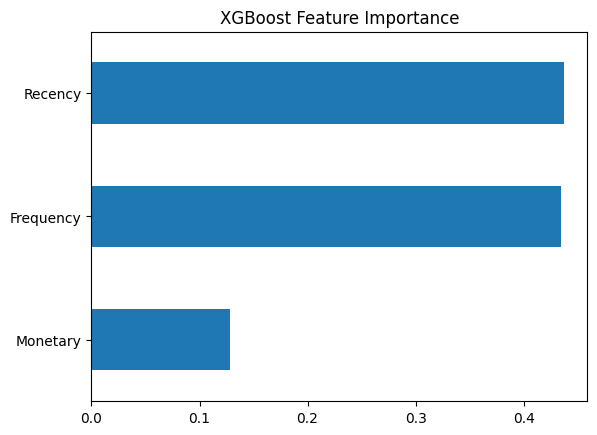

In [42]:
import matplotlib.pyplot as plt
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind='barh'
)

plt.title("XGBoost Feature Importance")

plt.show()

In [43]:
predictions = X_test.copy()

predictions['Actual'] = y_test

predictions['Purchase_Probability'] = y_prob

predictions.head()

,Recency,Frequency,Monetary,Actual,Purchase_Probability
Customer ID,,,,,
16163.0,202,6,2849.58,0,0.238172
17698.0,231,1,154.95,0,0.031987
15806.0,16,3,784.58,0,0.323802
14758.0,115,7,2864.97,0,0.353033
16481.0,652,1,453.38,0,0.012823


In [44]:
predictions = X_test.copy()

predictions['Actual'] = y_test

predictions['Purchase_Probability'] = y_prob

predictions.head()

,Recency,Frequency,Monetary,Actual,Purchase_Probability
Customer ID,,,,,
16163.0,202,6,2849.58,0,0.238172
17698.0,231,1,154.95,0,0.031987
15806.0,16,3,784.58,0,0.323802
14758.0,115,7,2864.97,0,0.353033
16481.0,652,1,453.38,0,0.012823


In [45]:
import joblib

joblib.dump(
    model,
    "../models/xgboost_propensity_model.pkl"
)

['../models/xgboost_propensity_model.pkl']

In [46]:
joblib.dump(
    scaler_ml,
    "../models/propensity_scaler.pkl"
)
predictions.to_csv(
    "../data/purchase_predictions.csv"
)

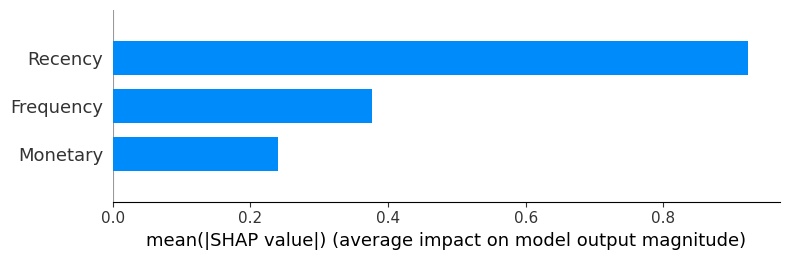

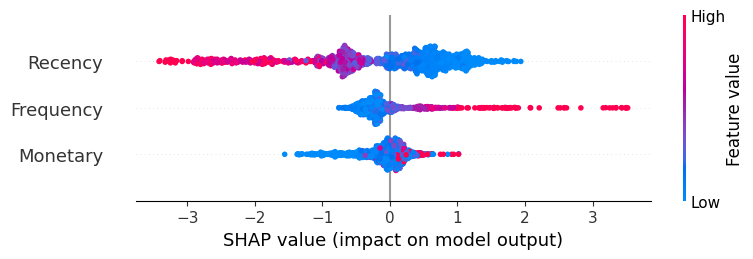

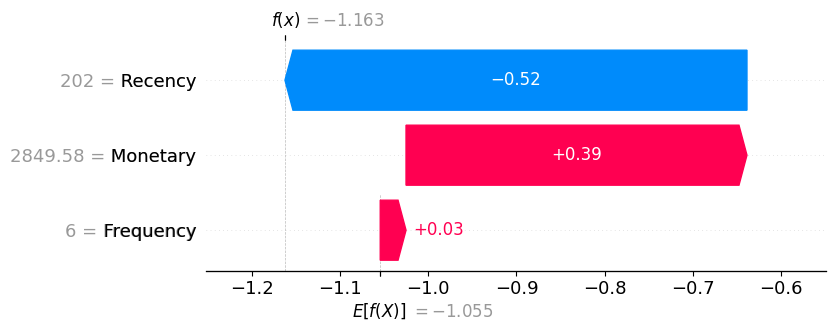

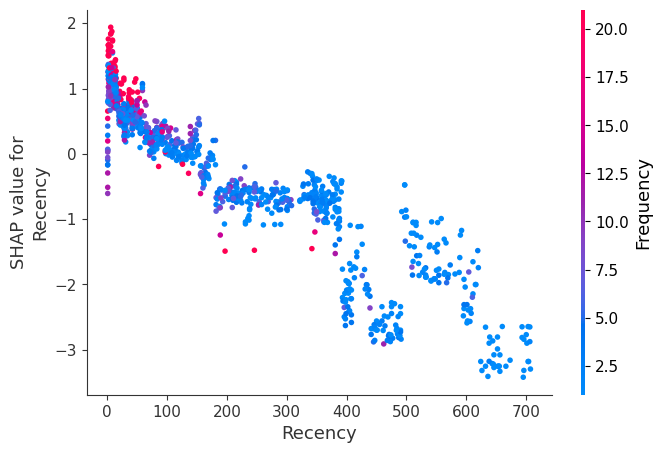

['../models/shap_explainer.pkl']

In [47]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(
    X_test_scaled
)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)
shap.summary_plot(
    shap_values,
    X_test
)
X_test.iloc[0]
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)
shap.dependence_plot(
    'Recency',
    shap_values,
    X_test
)
shap_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns
)
shap_df.to_csv(
    "../data/online_retail.csv/shap_values.csv",
    index=False
)
import joblib

joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)